# Simulación Matemática: Colector Solar en Espiral

Este notebook simula el rendimiento térmico de un colector solar de agua en espiral utilizando datos de radiación solar (`pvlib`) y condiciones meteorológicas reales (NASA).

### 1. Importación de Librerías

In [1]:
import polars as pl
import pandas as pd
import math
import pvlib
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

### 2. Parámetros y Constantes del Proyecto
Definición de coordenadas (Morelia, México), geometría del lente concentrador, propiedades ópticas y del serpentín.

In [2]:
# --- PARÁMETROS GEOGRÁFICOS ---
phi = 19.7008                   # Latitud
longitud = -101.1844            # Longitud
h_alt = 1.92                    # Altitud en km (Hottel)
altitud_m = 1920                # Altitud en m (pvlib)
zona_horaria = 'America/Mexico_City'

# --- MODELO DE HOTTEL Y SOL ---
Gsc = 1367                      # Constante Solar
Ao = 0.4237 - 0.00821 * (6 - h_alt)**2
A1 = 0.5055 + 0.00595 * (6.5 - h_alt)**2
K = 0.2711 + 0.01858 * (2.5 - h_alt)**2

# --- PROPIEDADES ÓPTICAS ---
radio_lente = 0.245
Aa = math.pi * (radio_lente**2)
tau_lente = 0.85
tau_vidrio = 0.90
alpha_cobre = 0.95
epsilon_p = 0.95

# --- PROPIEDADES TÉRMICAS ---
k_madera = 0.12
L_madera = 0.0254
Cp_agua = 4186
SIGMA = 5.67e-8

# --- GEOMETRÍA DEL SERPENTÍN ---
L_tubo_total = 15.0
D_exterior = 0.5 * 0.0254
D_interno = (3/8) * 0.0254
v_total_m3 = (math.pi * D_interno**2 / 4) * L_tubo_total
masa_total_kg = v_total_m3 * 1000

### 3. Estrategia de Vaciado Parcial y Área Efectiva
Optimización basada en procesar únicamente el 50% de la capacidad de agua por ciclo para un calentamiento rápido.

In [3]:
factor_vaciado = 0.5
m_agua_batch = masa_total_kg * factor_vaciado
v_litros_batch = m_agua_batch

# Área de pérdida efectiva (disco de la espiral)
area_perdida_efectiva = math.pi * (radio_lente**2)

print(f"Capacidad total: {masa_total_kg:.3f} kg")
print(f"Masa por lote (50%): {m_agua_batch:.3f} kg")
print(f"Área efectiva de pérdida: {area_perdida_efectiva:.4f} m²")

Capacidad total: 1.069 kg
Masa por lote (50%): 0.534 kg
Área efectiva de pérdida: 0.1886 m²


### 4. Preparación de Datos (PVLib y NASA)
Generación de datos de irradiancia y posición solar, combinados con las mediciones climáticas horarias de la NASA.

In [4]:
# Posición solar con PVLib
morelia = pvlib.location.Location(latitude=phi, longitude=longitud, tz=zona_horaria, altitude=altitud_m)
tiempos = pd.date_range(start='2025-01-01 00:00:00', end='2025-12-31 23:00:00', freq='60min', tz=zona_horaria)
df_solar_pd = morelia.get_solarposition(tiempos)

df_solar_pd = df_solar_pd.reset_index().rename(columns={'index': 'fecha_hora'})
df_solar_pd['fecha_hora'] = df_solar_pd['fecha_hora'].dt.tz_localize(None)
df_pl = pl.from_pandas(df_solar_pd)

# Datos NASA
df_nasa = pl.read_csv("Tabla datos NASA.csv", skip_rows=15)
cols = df_nasa.columns
df_nasa = df_nasa.select([
    pl.datetime(pl.col(cols[0]), pl.col(cols[1]), pl.col(cols[2]), pl.col(cols[3]))
      .dt.truncate("1h").dt.cast_time_unit("us").alias("fecha_hora"),
    pl.col(cols[7]).cast(pl.Float64).alias("temp_ambiente"),
    pl.col(cols[10]).cast(pl.Float64).alias("v_viento")
])

# Rango de temperatura del agua
Ti_c = 20.0
Tf_c = 94.0
Tp_prom_c = (Ti_c + Tf_c) / 2
Tp_k = Tp_prom_c + 273.15

# Alineación y unión
df_pl = df_pl.with_columns(pl.col("fecha_hora").dt.truncate("1h").dt.cast_time_unit("us"))
df_resultado = df_pl.join(df_nasa, on="fecha_hora")

### 5. Definición de Ecuaciones Térmicas (Polars)
Planteamiento de todas las expresiones matemáticas en variables de Polars para un cálculo vectorizado y rápido. Incluye cálculo por Newton-Raphson para la placa térmica.

In [5]:
altura_techo = 3.0
alpha_terreno = 0.22

# Variables independientes
expr_es_de_dia = (pl.col("zenith") < 90).alias("es_de_dia")
expr_ventana_prod = pl.col("fecha_hora").dt.hour().is_between(10, 18, closed="left").alias("ventana_productiva")
expr_ta_k = (pl.col("temp_ambiente") + 273.15).alias("Ta_k")
expr_e_lote = pl.lit(m_agua_batch * Cp_agua * (Tf_c - Ti_c)).alias("E_lote_joules")
expr_gon = (Gsc * (1 + 0.033 * ((360 * pl.col("fecha_hora").dt.ordinal_day() / 365) * math.pi / 180).cos())).alias("Gon")

# Ángulos y transferencia
expr_cos_theta_z = pl.when(pl.col("es_de_dia")).then((pl.col("zenith") * math.pi / 180).cos()).otherwise(1.0).alias("cos_theta_z")
expr_t_sky = (0.0552 * (pl.col("Ta_k")**1.5)).alias("T_sky")
expr_viento_real = (pl.col("v_viento") * (altura_techo / 10.0)**alpha_terreno).alias("v_viento_techo")
expr_hw = (5.7 + 3.8 * pl.col("v_viento_techo")).alias("hw")
expr_gb_n = (pl.col("Gon") * (Ao + A1 * (-K / pl.col("cos_theta_z")).exp())).alias("gb_n")

# Newton-Raphson
expr_Q_opt_base = (pl.col("gb_n") * Aa * tau_lente * alpha_cobre)
expr_Q_req = pl.lit(masa_total_kg * Cp_agua * (Tf_c - Ti_c) / 3600)
expr_Tp = pl.lit(Tp_k).alias("Tp_iter")

for _ in range(4):
    expr_f_Tp = expr_Q_opt_base - (pl.col("hw") * (expr_Tp - pl.col("Ta_k")) + epsilon_p * SIGMA * (expr_Tp**4 - pl.col("T_sky")**4)) * area_perdida_efectiva - expr_Q_req
    expr_df_Tp = -(pl.col("hw") + 4 * epsilon_p * SIGMA * (expr_Tp**3)) * area_perdida_efectiva
    expr_Tp = pl.when(pl.col("es_de_dia")).then(expr_Tp - (expr_f_Tp / expr_df_Tp)).otherwise(pl.col("Ta_k")).alias("Tp_iter")

expr_Tp_final_K = expr_Tp.alias("Tp_Placa_K")
expr_h_rad = (epsilon_p * SIGMA * (pl.col("Tp_Placa_K") + pl.col("T_sky")) * (pl.col("Tp_Placa_K")**2 + pl.col("T_sky")**2)).alias("h_rad")

# Coeficientes de pérdida y calor absorbido (CORREGIDO)
expr_u_l_desnudo = ((pl.col("hw") + pl.col("h_rad")) + (k_madera / L_madera)).alias("U_L_Desnudo")
expr_u_l_caja = (pl.lit(6.5) + (k_madera / L_madera)).alias("U_L_Caja")

expr_q_opt_desnudo = (pl.col("gb_n") * Aa * tau_lente * alpha_cobre).alias("Q_opt_Desnudo")
expr_q_opt_caja = (pl.col("gb_n") * Aa * tau_lente * tau_vidrio * alpha_cobre).alias("Q_opt_Caja")

expr_q_loss_desnudo = (pl.col("U_L_Desnudo") * area_perdida_efectiva * (Tp_prom_c - pl.col("temp_ambiente"))).alias("Q_loss_Desnudo")
expr_q_loss_caja = (pl.col("U_L_Caja") * area_perdida_efectiva * (Tp_prom_c - pl.col("temp_ambiente"))).alias("Q_loss_Caja")

expr_qu_desnudo = (pl.col("Q_opt_Desnudo") - pl.col("Q_loss_Desnudo")).alias("Qu_Desnudo_W")
expr_qu_caja = (pl.col("Q_opt_Caja") - pl.col("Q_loss_Caja")).alias("Qu_Caja_W")

expr_tiempo_herv = pl.when(pl.col("ventana_productiva") & (pl.col("Qu_Caja_W") > 0)).then((pl.col("E_lote_joules") / pl.col("Qu_Caja_W")) / 60).otherwise(None).alias("Tiempo_Hervir_min")
expr_litros_hora = pl.when(pl.col("Tiempo_Hervir_min") > 0).then((60 / pl.col("Tiempo_Hervir_min")) * v_litros_batch).otherwise(0.0).alias("Litros_Hora")
expr_eficiencia = pl.when(pl.col("gb_n") > 0).then((pl.col("Qu_Caja_W") / (pl.col("gb_n") * Aa)) * 100).otherwise(0.0).alias("Eficiencia_pct")
expr_ghi = (pl.col("gb_n") * pl.col("cos_theta_z")).alias("GHI")

### 6. Ejecución del Modelo en Cascada
Se aplican todas las transformaciones vectorizadas calculando los resultados hora a hora.

In [6]:
df_calculado = (
    df_resultado
    .with_columns([expr_es_de_dia, expr_ventana_prod, expr_ta_k, expr_viento_real, expr_e_lote, expr_gon])
    .with_columns([expr_cos_theta_z, expr_t_sky, expr_hw])
    .with_columns([expr_gb_n])
    .with_columns([expr_Tp_final_K])
    .with_columns([expr_h_rad])
    .with_columns([expr_u_l_desnudo, expr_u_l_caja])
    .with_columns([expr_q_opt_desnudo, expr_q_opt_caja])
    .with_columns([expr_q_loss_desnudo, expr_q_loss_caja])
    .with_columns([expr_qu_desnudo, expr_qu_caja])
    .with_columns([expr_tiempo_herv])
    .with_columns([expr_litros_hora, expr_eficiencia, expr_ghi])
)

df_resultados = (
    df_calculado
    .with_columns([
        pl.col("Litros_Hora").fill_null(0).cum_sum().over(pl.col("fecha_hora").dt.date()).alias("Litros_Acum_Dia")
    ])
    .with_columns([
        pl.when(pl.col("ventana_productiva") & (pl.col("Qu_Caja_W") > 0)).then(pl.lit(Tf_c)).otherwise(pl.lit(Ti_c)).alias("T_agua_final_C")
    ])
    .rename({"gb_n": "G_Directa_Normal"})
)

df_tabla_final = (
    df_resultados
    .filter(pl.col("ventana_productiva"))
    .select([
        "fecha_hora", "G_Directa_Normal", "v_viento_techo", "v_viento",
        "Qu_Desnudo_W", "Qu_Caja_W", "Tiempo_Hervir_min", "T_agua_final_C",
        "Eficiencia_pct", "Litros_Hora", "Litros_Acum_Dia"
    ])
)
print("Ejecución completa.")

Ejecución completa.


### 7. Análisis Visual del Rendimiento (Gráficas)
Visualización del comportamiento a lo largo del año, la eficiencia y los niveles de producción de agua caliente.

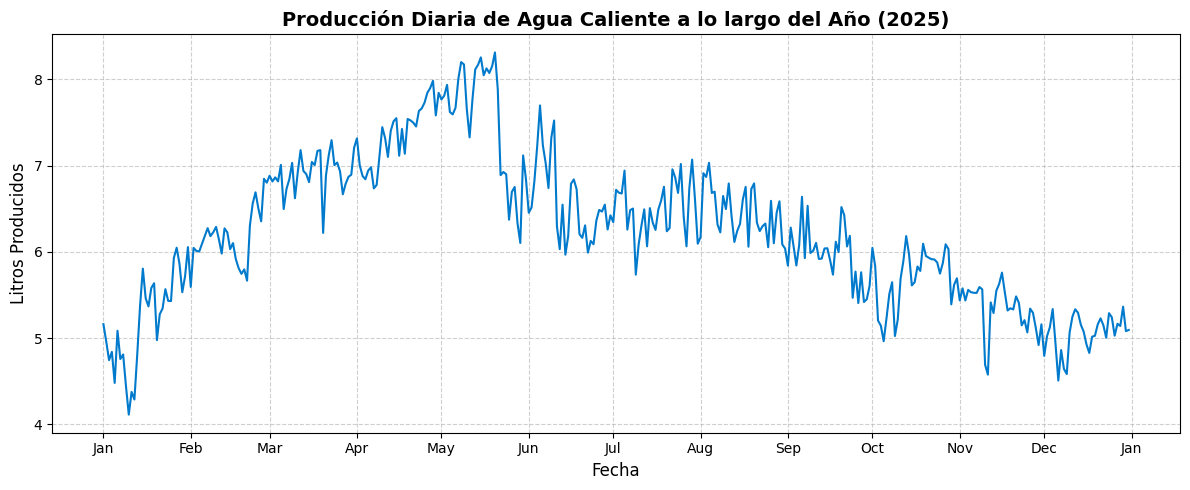

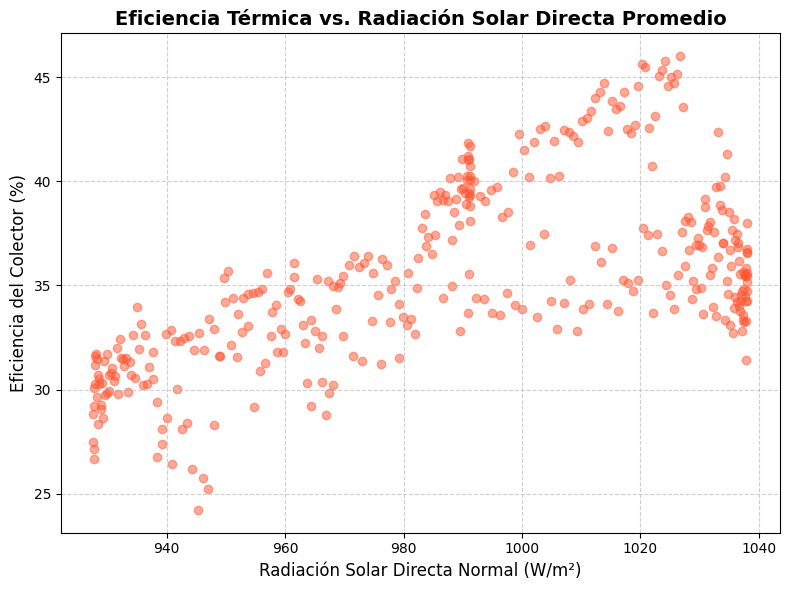

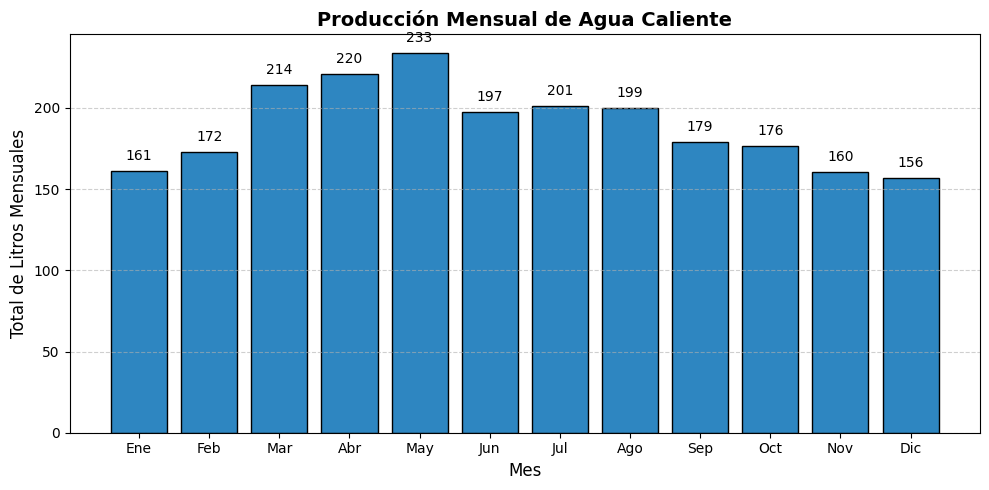

In [7]:
# Preparamos datos para las gráficas: Promedios y acumulados diarios
df_diario = (
    df_tabla_final.group_by_dynamic("fecha_hora", every="1d")
    .agg([
        pl.col(pl.Float64).exclude("Litros_Acum_Dia").mean(),
        pl.col("Litros_Acum_Dia").last().alias("Litros_Total_Dia"),
    ])
    .sort("fecha_hora")
)

df_diario_pd = df_diario.to_pandas()
df_diario_pd.set_index('fecha_hora', inplace=True)

# ----------------------------------------------------
# GRÁFICA 1: Producción Diaria de Litros a lo largo del año
# ----------------------------------------------------
plt.figure(figsize=(12, 5))
plt.plot(df_diario_pd.index, df_diario_pd['Litros_Total_Dia'], color='#007ACC', linewidth=1.5)
plt.title('Producción Diaria de Agua Caliente a lo largo del Año (2025)', fontsize=14, fontweight='bold')
plt.xlabel('Fecha', fontsize=12)
plt.ylabel('Litros Producidos', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%b'))
plt.gca().xaxis.set_major_locator(mdates.MonthLocator())
plt.tight_layout()
plt.show()

# ----------------------------------------------------
# GRÁFICA 2: Eficiencia vs. Radiación Solar Directa
# ----------------------------------------------------
plt.figure(figsize=(8, 6))
plt.scatter(df_diario_pd['G_Directa_Normal'], df_diario_pd['Eficiencia_pct'], alpha=0.5, color='#FF5733')
plt.title('Eficiencia Térmica vs. Radiación Solar Directa Promedio', fontsize=14, fontweight='bold')
plt.xlabel('Radiación Solar Directa Normal (W/m²)', fontsize=12)
plt.ylabel('Eficiencia del Colector (%)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

# ----------------------------------------------------
# GRÁFICA 3: Producción Total Mensual (Gráfico de Barras)
# ----------------------------------------------------
produccion_mensual = df_diario_pd['Litros_Total_Dia'].resample('ME').sum()
meses = ['Ene', 'Feb', 'Mar', 'Abr', 'May', 'Jun', 'Jul', 'Ago', 'Sep', 'Oct', 'Nov', 'Dic']

plt.figure(figsize=(10, 5))
barras = plt.bar(meses, produccion_mensual, color='#2E86C1', edgecolor='black')
plt.title('Producción Mensual de Agua Caliente', fontsize=14, fontweight='bold')
plt.xlabel('Mes', fontsize=12)
plt.ylabel('Total de Litros Mensuales', fontsize=12)

# Añadir etiquetas de valor a cada barra
for b in barras:
    yval = b.get_height()
    plt.text(b.get_x() + b.get_width()/2, yval + 5, f'{int(yval)}', ha='center', va='bottom', fontsize=10)

plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

### 8. Exportación de Resultados
Exportación de los resultados consolidados a un archivo Excel.

In [9]:
Resultados_tesis_KPVE = "modelado_colector_solar_anual.xlsx"

df_diario.write_excel(
    workbook=Resultados_tesis_KPVE,
    worksheet="Resultados Diarios Anuales",
    table_style="Table Style Medium 9",
    dtype_formats={pl.Float64: "#,##0.00"},
    column_formats={
        "fecha_hora": "YYYY-MM-DD",
        "Eficiencia_pct": "0.00",
        "Litros_Hora": "0.000",
        "Litros_Total_Dia": "#,##0.00",
    },
    autofit=True,
)

print(f"¡Éxito! Resultados guardados en: {Resultados_tesis_KPVE}")

¡Éxito! Resultados guardados en: modelado_colector_solar_anual.xlsx
